#  Sprint 4 — Análisis estadístico (diagnóstico)
**Insumo:** `mvnd_limpio.csv`

### Objetivos
- Probar asociación entre variables categóricas (chi-cuadrado)
- Medir fuerza con **V de Cramér**
- Responder: ¿urgencias y capítulos CIE-10 están asociados?


## Configuración


In [1]:
%pip install pandas matplotlib seaborn scipy openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys

RUTA_LIMPIO = '../datasets/mvnd_limpio.csv'


plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10
sns.set_theme(style='whitegrid', palette='muted')

CARPETA_GRAFICOS = '../graficos/Graficos_Diagnostico'
import os
os.makedirs(CARPETA_GRAFICOS, exist_ok=True)

def guardar(fig, nombre):
    ruta = os.path.join(CARPETA_GRAFICOS, nombre)
    fig.savefig(ruta, dpi=150, bbox_inches='tight')
    print(f' Guardado: {ruta}')

from scipy.stats import chi2_contingency



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
df = pd.read_csv(RUTA_LIMPIO, encoding='utf-8-sig')
df['FECHA_AUTORIZACION'] = pd.to_datetime(df['FECHA_AUTORIZACION'])

# Corregir nombre de columna año parcial (encoding en CSV)
for c in list(df.columns):
    if 'PARCIAL' in c.upper():
        df = df.rename(columns={c: 'ANIO_PARCIAL'})

print(f' Dataset cargado: {len(df):,} registros × {df.shape[1]} columnas')
print(f'   Período: {df["FECHA_AUTORIZACION"].min().date()} → {df["FECHA_AUTORIZACION"].max().date()}')


 Dataset cargado: 9,413 registros × 21 columnas
   Período: 2018-01-09 → 2026-06-12


## Funciones estadísticas


In [3]:

def cramers_v(tabla):
    chi2, _, _, _ = chi2_contingency(tabla)
    n = tabla.values.sum()
    r, k = tabla.shape
    return np.sqrt(chi2 / (n * min(r - 1, k - 1)))

def prueba_asociacion(df_sub, col_a, col_b, min_freq=5, titulo=''):
    tab = pd.crosstab(df_sub[col_a], df_sub[col_b])
    # Filtrar categorías muy pequeñas
    tab = tab.loc[tab.sum(axis=1) >= min_freq, tab.sum(axis=0) >= min_freq]
    chi2, p, dof, expected = chi2_contingency(tab)
    v = cramers_v(tab)
    print('=' * 60)
    print(titulo)
    print('=' * 60)
    print(f'Chi-cuadrado: {chi2:.2f}  |  gl: {dof}  |  p-valor: {p:.2e}')
    print(f"V de Cramér: {v:.3f}  → ", end='')
    if v < 0.1: print('asociación débil')
    elif v < 0.3: print('asociación moderada')
    else: print('asociación fuerte')
    print('Conclusión:', 'Asociación estadísticamente significativa (p<0.05)' if p < 0.05 else 'No significativa (p≥0.05)')
    return tab, chi2, p, v



## 1. TIPO_SOLICITUD × CAPITULO_CIE10


TIPO_SOLICITUD × CAPITULO_CIE10 (top 10 capítulos)
Chi-cuadrado: 4663.76  |  gl: 18  |  p-valor: 0.00e+00
V de Cramér: 0.510  → asociación fuerte
Conclusión: Asociación estadísticamente significativa (p<0.05)
 Guardado: ../graficos/Graficos_Diagnostico\07_chi2_tipo_capitulo.png


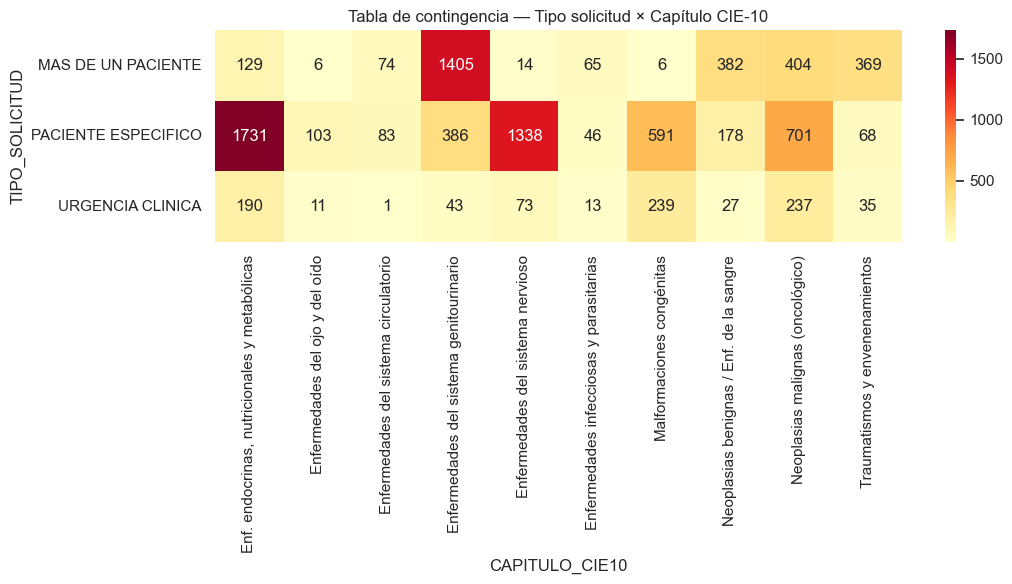

In [4]:

df_est = df[df['CAPITULO_CIE10'].notna()].copy()
# Top capítulos para tabla estable
top_cap = df_est['CAPITULO_CIE10'].value_counts().head(10).index
df_est = df_est[df_est['CAPITULO_CIE10'].isin(top_cap)]

tab1, chi2_1, p1, v1 = prueba_asociacion(
    df_est, 'TIPO_SOLICITUD', 'CAPITULO_CIE10',
    titulo='TIPO_SOLICITUD × CAPITULO_CIE10 (top 10 capítulos)'
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(tab1, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Tabla de contingencia — Tipo solicitud × Capítulo CIE-10')
plt.tight_layout()
guardar(plt.gcf(), '07_chi2_tipo_capitulo.png')
plt.show()



## 2. ES_URGENCIA × CAPITULO_CIE10


URGENCIA × CAPITULO_CIE10
Chi-cuadrado: 619.94  |  gl: 9  |  p-valor: 1.10e-127
V de Cramér: 0.263  → asociación moderada
Conclusión: Asociación estadísticamente significativa (p<0.05)
 Guardado: ../graficos/Graficos_Diagnostico\07_pct_urgencia_por_capitulo.png


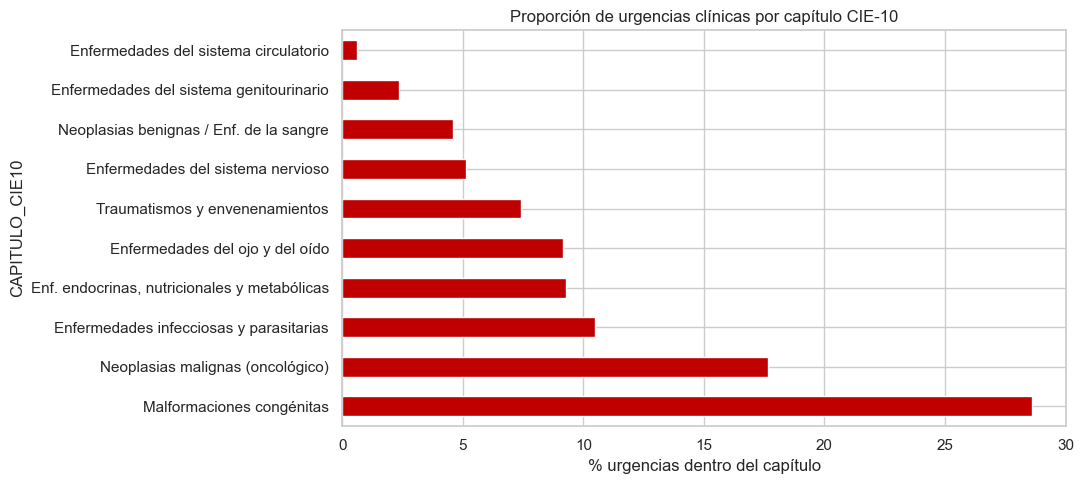

CAPITULO_CIE10
Malformaciones congénitas                       28.59
Neoplasias malignas (oncológico)                17.66
Enfermedades infecciosas y parasitarias         10.48
Enf. endocrinas, nutricionales y metabólicas     9.27
Enfermedades del ojo y del oído                  9.17
Traumatismos y envenenamientos                   7.42
Enfermedades del sistema nervioso                5.12
Neoplasias benignas / Enf. de la sangre          4.60
Enfermedades del sistema genitourinario          2.34
Enfermedades del sistema circulatorio            0.63
Name: ES_URGENCIA, dtype: float64


In [5]:

df_est2 = df[df['CAPITULO_CIE10'].notna()].copy()
df_est2['URGENCIA'] = df_est2['ES_URGENCIA'].map({0: 'No urgencia', 1: 'Urgencia clínica'})
top_cap2 = df_est2['CAPITULO_CIE10'].value_counts().head(10).index
df_est2 = df_est2[df_est2['CAPITULO_CIE10'].isin(top_cap2)]

tab2, chi2_2, p2, v2 = prueba_asociacion(
    df_est2, 'URGENCIA', 'CAPITULO_CIE10',
    titulo='URGENCIA × CAPITULO_CIE10'
)

# % urgencia por capítulo
pct_urg = df_est2.groupby('CAPITULO_CIE10')['ES_URGENCIA'].mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(11, 5))
pct_urg.plot(kind='barh', ax=ax, color='#c00000')
ax.set_xlabel('% urgencias dentro del capítulo')
ax.set_title('Proporción de urgencias clínicas por capítulo CIE-10')
plt.tight_layout()
guardar(plt.gcf(), '07_pct_urgencia_por_capitulo.png')
plt.show()
print(pct_urg.round(2))



## 3. TIPO_SOLICITUD × FORMA_FARMACEUTICA (top categorías)


TIPO_SOLICITUD × FORMA_FARMACEUTICA (top 8)
Chi-cuadrado: 3870.77  |  gl: 14  |  p-valor: 0.00e+00
V de Cramér: 0.480  → asociación fuerte
Conclusión: Asociación estadísticamente significativa (p<0.05)
 Guardado: ../graficos/Graficos_Diagnostico\07_chi2_tipo_forma.png


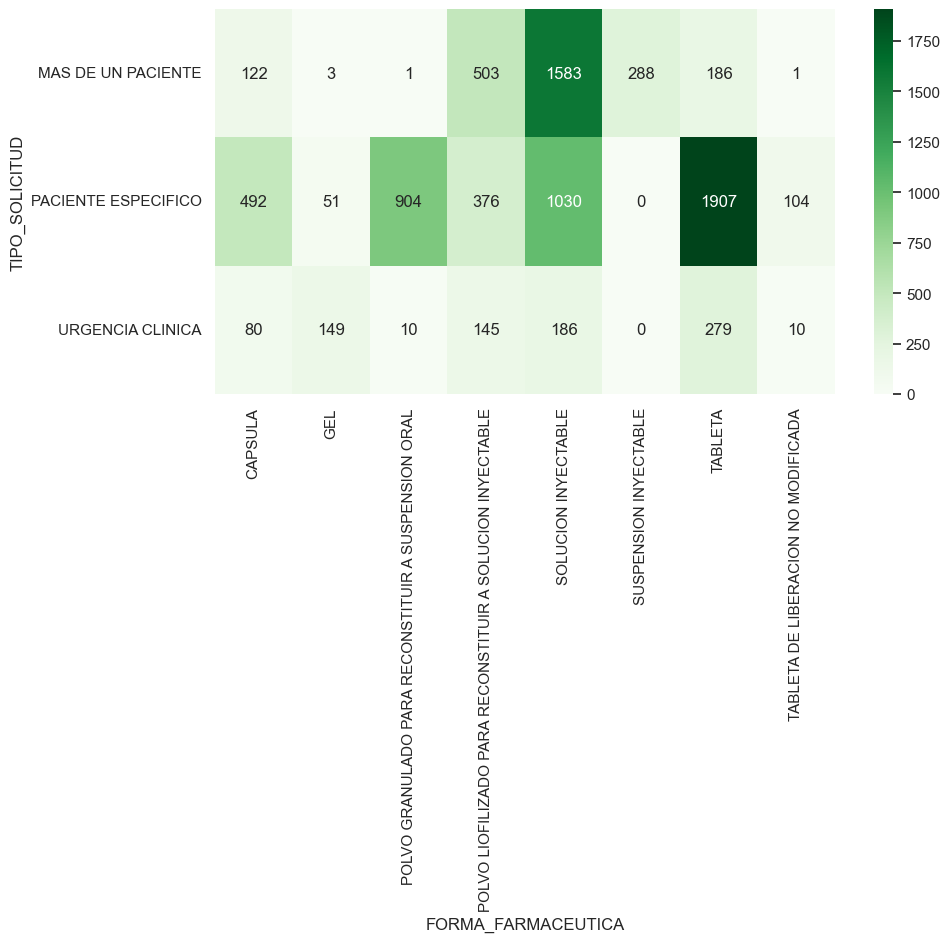

In [6]:

top_f = df['FORMA_FARMACEUTICA'].value_counts().head(8).index
df_f = df[df['FORMA_FARMACEUTICA'].isin(top_f)]
tab3, chi2_3, p3, v3 = prueba_asociacion(
    df_f, 'TIPO_SOLICITUD', 'FORMA_FARMACEUTICA',
    titulo='TIPO_SOLICITUD × FORMA_FARMACEUTICA (top 8)'
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(tab3, annot=True, fmt='d', cmap='Greens', ax=ax)
plt.tight_layout()
guardar(plt.gcf(), '07_chi2_tipo_forma.png')
plt.show()



## 4. Resumen de pruebas


In [8]:

resumen = pd.DataFrame([
    {'Comparación': 'TIPO_SOLICITUD × CAPITULO_CIE10', 'Chi2': chi2_1, 'p_valor': p1, 'Cramers_V': v1},
    {'Comparación': 'URGENCIA × CAPITULO_CIE10', 'Chi2': chi2_2, 'p_valor': p2, 'Cramers_V': v2},
    {'Comparación': 'TIPO_SOLICITUD × FORMA_FARMACEUTICA', 'Chi2': chi2_3, 'p_valor': p3, 'Cramers_V': v3},
])
resumen['Significativo (p<0.05)'] = resumen['p_valor'] < 0.05
display(resumen.round(4))




,Comparación,Chi2,p_valor,Cramers_V,Significativo (p<0.05)
0,TIPO_SOLICITUD × CAPITULO_CIE10,4663.7637,0.0,0.5105,True
1,URGENCIA × CAPITULO_CIE10,619.9377,0.0,0.2632,True
2,TIPO_SOLICITUD × FORMA_FARMACEUTICA,3870.7651,0.0,0.4797,True


##  Hallazgos — Análisis estadístico

| Prueba | Interpretación típica |
|--------|------------------------|
| TIPO × Capítulo | El tipo de solicitud **no se distribuye al azar** entre enfermedades (capítulos CIE-10) |
| Urgencia × Capítulo | Algunos capítulos presentan **mayor proporción** de urgencias clínicas |
| TIPO × Forma farmacéutica | Coherencia entre vía farmacéutica y mecanismo de solicitud |

> **Nota metodológica:** Con n > 10.000, el chi-cuadrado casi siempre es significativo; priorizar **V de Cramér** para interpretar la fuerza del efecto.

**Entregables finales:** Dashboard Power BI + informe ejecutivo.

---
*Proyecto MVND INVIMA — Unicomfacauca 2026*
